# Bayesian Optimization for Cu₃VS₄ Nanoparticle Synthesis

**Purpose**: Multi-objective optimization of size, GSD, and squareness across target sizes

**Date**: January 2026  
**Author**: Ari

## Features
- Size-constrained Bayesian optimization
- Multi-objective optimization (minimize GSD, maximize Squareness)
- Feasibility modeling (HasProduct, PhasePure, IsCubic)
- Pareto front analysis
- Adaptive surrogate with experimental tracking


# ⚠️ IMPORTANT: Fixes Applied

This notebook has been peer-reviewed and corrected. Key fixes:

1. **Fixed class structure**: `beta()` method moved outside `__init__`
2. **Fixed pip install syntax**: Converted to proper Python subprocess call
3. **Added warnings**: Beta parameter is computed but NOT used in EI acquisition
4. **Code cleaned**: Removed structural errors

## ⚠️ Known Limitations

- **Independence assumption**: Constraint probabilities assume independence (may not hold)
- **Beta unused**: Exploration parameter `beta` is tracked but not used in acquisition
- **Homoscedastic noise**: GP assumes constant noise (may not match TEM measurements)

**See peer_review_report.md for complete analysis**

---


In [ ]:
# =========================
# ALL IMPORTS
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from dataclasses import dataclass
from typing import List, Dict, Tuple
from datetime import datetime
import uuid
import os
import sys
# Optional dependency: PyArrow improves pandas IO speed (esp. parquet/arrow).
# If you do NOT need it, you can comment this line out.
# Optional: Install pyarrow for better pandas performance
# Run this once if needed:
# import subprocess; subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pyarrow"])

# Scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor, GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C
from sklearn.metrics import r2_score, roc_auc_score
from sklearn.model_selection import LeaveOneOut, cross_val_predict

# Scipy
from scipy.stats import norm, qmc
from scipy.spatial.distance import cdist

# Joblib for saving/loading
import joblib

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


## 1. Data Loading

Load your experimental data. Update the path to point to your CSV file.


In [4]:
# =========================
# DATA PATH (reproducible)
# =========================
# Paper-grade reproducibility note:
# - Avoid hard-coded personal file paths in the notebook.
# - Prefer a project-relative path OR an environment variable so collaborators can run it unchanged.
#
# Option A (recommended): keep the CSV in ./Data/ and use the default below.
# Option B: set an env var before launching Jupyter:
#     export CUVS_DATA_CSV="/full/path/to/COMPLETE_CUVS_DATA_SIDE2.csv"
#
# NOTE: Path.cwd() is the *working directory* where you launch Jupyter from.
from pathlib import Path

DEFAULT_RELATIVE = Path("Data") / "COMPLETE_CUVS_DATA_SIDE2.csv"
DATA_PATH = Path(os.getenv("CUVS_DATA_CSV", DEFAULT_RELATIVE)).expanduser()

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find the dataset CSV at: {DATA_PATH}\n"
        "Fix options:\n"
        "  1) Put the file at ./Data/COMPLETE_CUVS_DATA_SIDE2.csv (relative to your notebook working directory), or\n"
        "  2) Set environment variable CUVS_DATA_CSV to the file path.\n"
        "Tip: in Jupyter, you can also print(Path.cwd()) to confirm the working directory."
    )

# Load data
df = pd.read_csv(DATA_PATH)

print(f"Loaded {len(df)} experiments from: {DATA_PATH.resolve()}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst few rows:")
display(df.head())


Loaded 41 experiments

Columns: ['Temp', 'Time', 'VOacac', 'DDT', 'OAm', 'Run_ID', 'GSD', 'Squareness', 'Size', 'PhasePure', 'HasProduct', 'Polymorph']

First few rows:
   Temp  Time  VOacac  DDT  OAm  Run_ID     GSD  Squareness    Size  \
0   260     8    0.08  1.0  7.0       1     NaN         NaN     NaN   
1   260     8    0.08  5.0  1.0       2     NaN         NaN     NaN   
2   260     8    0.66  1.0  1.0       3     NaN         NaN     NaN   
3   260     8    0.66  5.0  7.0       4     NaN         NaN     NaN   
4   260    90    0.08  1.0  1.0       5  1.7058       0.502  11.241   

   PhasePure  HasProduct Polymorph  
0          0           0       NaN  
1          0           0       NaN  
2          0           0       NaN  
3          0           0       NaN  
4          0           1     cubic  


## 2. Configuration

Define factor names, bounds, and objective weights.


In [5]:
# =========================
# Column configuration
# =========================
FACTOR_ORDER = ["Temp", "Time", "VOacac", "DDT", "OAm"]
OBJECTIVES = ["Size", "GSD", "Squareness"]
FEAS_COLS = ["HasProduct", "PhasePure"]  # required

# If your dataset includes a polymorph column:
POLYMORPH_COL = "Polymorph"  # set to None if you don't have it
CUBIC_LABEL = "cubic"          # e.g. "cubic" if df["Polymorph"] uses that string for cubic

# =========================
# Bounds (edit if needed)
# =========================
# These are the feasible ranges the optimizer will search within.
# If you already have chemistry-based hard bounds, set them here.
BOUNDS = {
    "Temp":   (260.0, 310.0),
    "Time":   (8.0,   90.0),
    "VOacac": (0.08,  0.66),
    "DDT":    (1.0,   5.0),
    "OAm":    (1.0,   7.0),
}

# =========================
# Dataset sanity checks
# =========================
missing = [c for c in (FACTOR_ORDER + OBJECTIVES + FEAS_COLS) if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Coerce key numeric columns to numeric (bad strings become NaN, which we can handle explicitly)
for c in FACTOR_ORDER + OBJECTIVES:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Basic NaN handling: drop rows that are missing any factor or objective.
# (If you want imputation, we can do that, but BO is better with clean labels.)
df = df.dropna(subset=FACTOR_ORDER).reset_index(drop=True)

print("Clean rows after dropping NaNs in factors/objectives:", len(df))

# Ensure feasibility columns are 0/1-ish (convert bool, "Yes"/"No", etc. as needed)
def to_binary(series: pd.Series) -> pd.Series:
    s = series.copy()
    if s.dtype == bool:
        return s.astype(int)
    # Common encodings
    mapping = {
        "yes": 1, "y": 1, "true": 1, "t": 1,
        "no": 0, "n": 0, "false": 0, "f": 0,
    }
    if s.dtype == object:
        s = s.astype(str).str.strip().str.lower().map(mapping).fillna(s)
    return pd.to_numeric(s, errors="coerce").fillna(0).astype(int)

for c in FEAS_COLS:
    df[c] = to_binary(df[c])

# Optional cubic feasibility derived from Polymorph if available and you specify CUBIC_LABEL.
# Safety: if you *intend* to enforce cubic but the column is missing, we hard-error rather than silently treating all as cubic.
USE_CUBIC_CONSTRAINT = (POLYMORPH_COL is not None) and (CUBIC_LABEL is not None)

if USE_CUBIC_CONSTRAINT:
    if POLYMORPH_COL not in df.columns:
        raise ValueError(
            f"POLYMORPH_COL='{POLYMORPH_COL}' was set, but that column is not present in df. "
            "Either add the polymorph column or set POLYMORPH_COL=None (and/or CUBIC_LABEL=None) to disable the cubic constraint."
        )
    df["IsCubic"] = (
        df[POLYMORPH_COL].astype(str).str.strip().str.lower()
        == str(CUBIC_LABEL).strip().lower()
    ).astype(int)
else:
    # Explicitly unconstrained in cubic dimension.
    df["IsCubic"] = 1

print(df[FEAS_COLS + ["IsCubic"]].describe())


Clean rows after dropping NaNs in factors/objectives: 41
       HasProduct  PhasePure    IsCubic
count   41.000000  41.000000  41.000000
mean     0.756098   0.414634   0.658537
std      0.434769   0.498779   0.480091
min      0.000000   0.000000   0.000000
25%      1.000000   0.000000   0.000000
50%      1.000000   0.000000   1.000000
75%      1.000000   1.000000   1.000000
max      1.000000   1.000000   1.000000


## 3. Utility Functions

Helper functions for constraints, normalization, and acquisition.


In [6]:
# =========================
# Constraints
# =========================
@dataclass
class Constraint:
    # Minimum allowed value of a factor.
    min_val: float
    # Maximum allowed value of a factor.
    max_val: float

def get_default_constraints(bounds: Dict[str, Tuple[float, float]]) -> Dict[str, Constraint]:
    # Turn simple numeric bounds into Constraint objects for consistency.
    return {k: Constraint(v[0], v[1]) for k, v in bounds.items()}

constraints = get_default_constraints(BOUNDS)

# =========================
# Normalization helpers
# =========================
def fit_scaler(X: np.ndarray) -> StandardScaler:
    # Standardize factors so all dimensions contribute comparably to distance and kernel lengthscales.
    scaler = StandardScaler()
    scaler.fit(X)
    return scaler

# =========================
# Acquisition helpers (principled)
# =========================
from scipy.stats import norm

def expected_improvement_min(mu: np.ndarray, sigma: np.ndarray, best: float) -> np.ndarray:
    """Expected Improvement for a *minimization* objective under Normal(mu, sigma)."""
    sigma = np.maximum(sigma, 1e-12)
    z = (best - mu) / sigma
    return (best - mu) * norm.cdf(z) + sigma * norm.pdf(z)

def pareto_mask_2d_minmax(x_min: np.ndarray, y_max: np.ndarray) -> np.ndarray:
    """Pareto non-dominated mask for 2 objectives: minimize x_min, maximize y_max."""
    x = np.asarray(x_min, dtype=float)
    y = np.asarray(y_max, dtype=float)
    n = len(x)
    keep = np.ones(n, dtype=bool)
    for i in range(n):
        if not keep[i]:
            continue
        dom = (x <= x[i]) & (y >= y[i]) & ((x < x[i]) | (y > y[i]))
        if np.any(dom):
            keep[i] = False
    return keep


# =========================
# Target size probabilistic constraint
# =========================
def prob_size_within_band(mu: np.ndarray, sigma: np.ndarray, target: float, tol: float) -> np.ndarray:
    # If sigma is 0 (or extremely small), clamp it to avoid divide-by-zero.
    sigma = np.maximum(sigma, 1e-9)

    # Compute probability that Size lies within [target - tol, target + tol] under Normal(mu, sigma).
    z_hi = (target + tol - mu) / sigma
    z_lo = (target - tol - mu) / sigma
    return norm.cdf(z_hi) - norm.cdf(z_lo)


## 4. Gaussian Process Model Builders

Define GP regressors and classifiers with appropriate kernels.


In [7]:
# =========================
# GP builders
# =========================
def make_gp_regressor(n_features: int) -> GaussianProcessRegressor:
    # Constant * ARD-RBF + White noise for robust regression.
    kernel = (
        C(1.0, (0.01, 100.0)) *  # Wider constant bounds
        RBF(length_scale=[1.0]*n_features, length_scale_bounds=(0.01, 100.0)) +  # Wider lengthscale bounds
        WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-8, 1.0))
    )
    return GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=8,  # More restarts
        random_state=42
    )

def make_gp_classifier(n_features: int) -> GaussianProcessClassifier:
    # GP classifier with ARD RBF kernel (no WhiteKernel; classification handles noise differently).
    kernel = (
        C(1.0, (0.01, 100.0)) * 
        RBF(length_scale=[1.0]*n_features, length_scale_bounds=(0.01, 100.0))
    )
    return GaussianProcessClassifier(
        kernel=kernel,
        n_restarts_optimizer=6,
        random_state=42,
        max_iter_predict=200
    )

def make_gp_regressor_gsd(n_features: int) -> GaussianProcessRegressor:
    # Slightly tighter ARD bounds + smaller noise bounds for GSD stability.
    # Designed for modeling log(GSD).
    kernel = (
        C(1.0, (0.01, 100.0)) *
        RBF(length_scale=[1.0]*n_features, length_scale_bounds=(0.01, 10.0)) +
        WhiteKernel(noise_level=0.05, noise_level_bounds=(1e-6, 0.5))
    )
    return GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=10,
        random_state=42
    )


## 5. Bayesian Optimization Class

Main TargetedConstrainedBO class with adaptive surrogate capabilities.

**Key Features**:
- Size-targeted recommendations
- Multi-objective optimization (GSD, Squareness)
- Feasibility constraints (HasProduct, PhasePure, IsCubic)
- Log-transform for GSD modeling (improves stability)
- Experimental tracking and model refitting


In [ ]:
class TargetedConstrainedBO:
    """
    Targeted constrained Bayesian Optimization (BO) for Cu₃VS₄ synthesis.

    Chemistry-paper mapping (high level):
      - Fit GP regressors for Size, log(GSD) (optional), and Squareness.
      - Fit GP classifiers for feasibility (HasProduct, PhasePure, optional IsCubic).
      - Score candidates with a constrained acquisition: EI × P(size in band) × P(feasible).
      - Return top-N diverse, feasible recommendations.

    Key assumptions to state explicitly:
      - Multiplying constraint probabilities assumes conditional independence.
      - GP uncertainty is treated as meaningful for decision-making (calibration matters).
      - Noise is approximated via WhiteKernel (often homoscedastic).
    """
    def __init__(
        self,
        df: pd.DataFrame,
        factor_order: List[str],
        constraints: Dict[str, Constraint],
        objective_weights: Dict[str, float],
        polymorph_col: str | None = None,
        cubic_label: str | None = None,
        use_cubic_constraint: bool = True,
    ):
        """
        Initialize the BO engine with data, bounds, and modeling knobs.
        
        Parameters:
          df: experiment table containing factors + objective columns + feasibility labels.
          bounds: dict mapping factor -> (min, max) search range.
          objective_weights: weights used to build the scalar utility from normalized objectives.
          gsd_log: if True, model log(GSD) rather than GSD.
          random_state: seed for reproducibility (affects GP restarts and sampling).
        
        Chemistry note:
          If property targets come from TEM-derived statistics, consider adding replicate / measurement-error metadata
          and upgrading the noise model (heteroscedastic) for a stronger 'digital twin' claim.
        """
        # Store the raw dataset (we'll append rows as you run new experiments).
        self.df_feas = df.copy()

        # Define factor ordering (controls column order for model training and candidate arrays).
        self.factor_order = factor_order

        # Store hard bounds/constraints for sampling.
        self.constraints = constraints

        # Store objective weights for combining acquisition components (squareness vs GSD).
        self.objective_weights = objective_weights


        # Polymorph / cubic constraint configuration (stored on the instance for safe save/load).
        self.polymorph_col = polymorph_col
        self.cubic_label = cubic_label
        self.use_cubic_constraint = bool(use_cubic_constraint) and (self.polymorph_col is not None) and (self.cubic_label is not None)

        # Only successful experiments for property regression
        self.df_props = df[df["HasProduct"] == 1].copy()

        if len(self.df_props) < 5:
            raise ValueError("Not enough successful experiments to train property models.")

        # Objective normalization (min/max from observed data) for scalarized utility EI.

        # Objective normalization (min/max from observed data) for scalarized utility EI.
        def _col_minmax(col: str) -> tuple[float, float]:
            vals = self.df_feas.loc[self.df_feas["HasProduct"] == 1, col].astype(float)
            vals = vals.replace([np.inf, -np.inf], np.nan).dropna().values
            if len(vals) < 2:
                raise ValueError(f"Not enough non-NaN '{col}' values to compute scaling.")
            vmin, vmax = float(np.min(vals)), float(np.max(vals))
            if abs(vmax - vmin) < 1e-12:
                vmax = vmin + 1e-6
            return vmin, vmax


        self._gsd_min, self._gsd_max = _col_minmax("GSD")
        self._sq_min, self._sq_max = _col_minmax("Squareness")

        # Fit scaler on ALL experiments (important!)
        self.X_feas_raw = self.df_feas[self.factor_order].values.astype(float)
        self.scaler = fit_scaler(self.X_feas_raw)

        # Normalized versions
        self.X_feas = self.scaler.transform(self.X_feas_raw)
        self.X_props = self.scaler.transform(
            self.df_props[self.factor_order].values.astype(float)
        )

        # Build regression GPs for objectives
        self.gp_size = make_gp_regressor(len(self.factor_order))
        self.gp_gsd = make_gp_regressor_gsd(len(self.factor_order))  # ← CHANGED
        self.gsd_transform = "log"  # ← ADDED - set transform flag
        self.gp_sq = make_gp_regressor(len(self.factor_order))

        # Fit models
        self.gp_size.fit(
            self.X_props,
            self.df_props["Size"].values.astype(float)
        )

        # Fit GSD on log-transformed values  # ← CHANGED
        gsd_raw = self.df_props["GSD"].values.astype(float)
        gsd_log = np.log(np.clip(gsd_raw, 1e-12, np.inf))
        self.gp_gsd.fit(self.X_props, gsd_log)

        self.gp_sq.fit(
            self.X_props,
            self.df_props["Squareness"].values.astype(float)
        )

        # Build GP classifiers for feasibility.
        self.clf_product = self._fit_feasibility_classifier(
            self.df_feas["HasProduct"].values, "HasProduct"
        )

        self.clf_pure = self._fit_feasibility_classifier(
            self.df_feas["PhasePure"].values, "PhasePure"
        )
        if self.use_cubic_constraint:
            if "IsCubic" not in self.df_feas.columns:
                raise ValueError("Cubic constraint enabled but df is missing 'IsCubic' column.")
            self.clf_cubic = self._fit_feasibility_classifier(
                self.df_feas["IsCubic"].values, "IsCubic"
            )
        else:
            self.clf_cubic = None

        # Iteration tracking table (fills during optimize()).
        self.history = []


    def beta(self, t: int, beta_start: float = 2.0, beta_growth: float = 0.05) -> float:
        """
        Exploration coefficient schedule (βₜ) for UCB-style confidence bounds.

        NOTE: Currently not used in acquisition function (which uses EI).
        Retained for compatibility and potential future UCB implementation.
        """
        t = int(max(0, t))
        return float(beta_start * (1.0 + beta_growth * t))

    def _fit_feasibility_classifier(self, y: np.ndarray, name: str):
        """
        Fit a GP feasibility classifier if both classes (0/1) exist.
        If only one class is present, return None (always feasible).
        """
        unique = np.unique(y)

        if len(unique) < 2:
            print(f"[INFO] {name}: only one class present ({unique[0]}). Treating as always feasible.")
            return None

        clf = make_gp_classifier(len(self.factor_order))
        clf.fit(self.X_feas, y.astype(int))
        return clf

    # --------------------------
    # Candidate sampling
    # --------------------------
    def sample_candidates(self, n: int, seed: int | None = None) -> np.ndarray:
        """Space-filling candidate sampling using Sobol (low-discrepancy)."""
        from scipy.stats import qmc
        lows = np.array([self.constraints[k].min_val for k in self.factor_order], dtype=float)
        highs = np.array([self.constraints[k].max_val for k in self.factor_order], dtype=float)
        sampler = qmc.Sobol(d=len(self.factor_order), scramble=True, seed=seed)
        X01 = sampler.random(n=n)
        return qmc.scale(X01, lows, highs)

    # --------------------------
    # Core predictor bundle
    # --------------------------
    def predict_all(self, Xcand_raw: np.ndarray):
        """
        Predict mean/std for all surrogate targets for a batch of candidates.
        
        Returns:
          (mu_size, sd_size, mu_log_gsd, sd_log_gsd, mu_squareness, sd_squareness,
           p_hasproduct, p_phasepure, p_iscubic)
        
        Notes:
          - For GSD we model log(GSD) for numerical stability; callers can exponentiate if needed.
          - Classifier outputs are probabilities in [0, 1] from GP classification.
        """
        # Normalize candidates so they match the GP training space.
        Xcand = self.scaler.transform(Xcand_raw)

        # Regression predictions (mean + std) for each objective.
        mu_s, sd_s = self.gp_size.predict(Xcand, return_std=True)
        mu_g, sd_g = self.predict_reg("GSD", Xcand)
        mu_q, sd_q = self.gp_sq.predict(Xcand, return_std=True)

        # Classification probabilities for feasibility (probability of class 1).
        p_prod = (
            np.ones(len(Xcand))
            if self.clf_product is None
            else self.clf_product.predict_proba(Xcand)[:, 1]
        )
        p_pure = (
            np.ones(len(Xcand))
            if self.clf_pure is None
            else self.clf_pure.predict_proba(Xcand)[:, 1]
        )
        p_cub = (
            np.ones(len(Xcand))
            if self.clf_cubic is None
            else self.clf_cubic.predict_proba(Xcand)[:, 1]
        )

        # If cubic constraint is disabled, do not penalize by cubic probability.
        if not self.use_cubic_constraint:
            p_cub = np.ones(len(Xcand))

        return (mu_s, sd_s, mu_g, sd_g, mu_q, sd_q, p_prod, p_pure, p_cub)


    # --------------------------
    # Convenience prediction helpers (for diagnostics / plotting)
    # --------------------------
    def predict_p_feasible(self, X: np.ndarray) -> np.ndarray:
        """Joint feasibility probability.

        Accepts either RAW inputs (in physical units) or already SCALED inputs.
        If values fall inside the configured raw bounds, they are treated as raw and scaled once.
        """
        X = np.asarray(X, dtype=float)
        # Determine whether X is raw or already scaled by checking raw bounds.
        lows = np.array([self.constraints[k].min_val for k in self.factor_order], dtype=float)
        highs = np.array([self.constraints[k].max_val for k in self.factor_order], dtype=float)

        is_raw = (X.shape[1] == len(lows)) and np.all(X >= (lows - 1e-9)) and np.all(X <= (highs + 1e-9))
        Xcand = self.scaler.transform(X) if is_raw else X

        p_prod = np.ones(len(Xcand)) if self.clf_product is None else self.clf_product.predict_proba(Xcand)[:, 1]
        p_pure = np.ones(len(Xcand)) if self.clf_pure is None else self.clf_pure.predict_proba(Xcand)[:, 1]

        if self.use_cubic_constraint and (self.clf_cubic is not None):
            p_cub = self.clf_cubic.predict_proba(Xcand)[:, 1]
        else:
            p_cub = np.ones(len(Xcand))

        return p_prod * p_pure * p_cub

    def prob_size_within_band(self, X_scaled: np.ndarray, target: float, tol: float) -> np.ndarray:
        """P(Size in [target±tol]) from GP posterior. Expects *scaled* X."""
        mu, sd = self.gp_size.predict(X_scaled, return_std=True)
        return prob_size_within_band(mu, sd, target, tol)

    def predict_reg(self, name: str, X_scaled: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
        """Predict mean/std for Size, GSD, or Squareness. Expects *scaled* X."""
        key = (name or "").strip().lower()
        if key in ("size",):
            return self.gp_size.predict(X_scaled, return_std=True)
        if key in ("gsd",):
            mu, sd = self.gp_gsd.predict(X_scaled, return_std=True)
            if getattr(self, "gsd_transform", "raw") == "log":
                # Lognormal moments for GSD (GP predicts log(GSD) ~ N(mu, sd^2))
                mu_gsd = np.exp(mu + 0.5 * (sd ** 2))
                var_gsd = (np.exp(sd ** 2) - 1.0) * np.exp(2.0 * mu + (sd ** 2))
                sd_gsd = np.sqrt(np.maximum(var_gsd, 0.0))
                return mu_gsd, sd_gsd
            return mu, sd
        if key in ("squareness", "sq"):
            return self.gp_sq.predict(X_scaled, return_std=True)
        raise ValueError(f"Unknown regression target: {name}")


    # --------------------------
    # Acquisition scoring under target-size constraint
    # --------------------------
    
    def score_candidates(
        self,
        Xcand_raw: np.ndarray,
        target_size: float,
        size_tol: float,
        p_size_min: float,
        p_feas_min: float,
    ):
        """
        Compute constrained acquisition scores for a raw candidate matrix.
        
        Outputs:
          - score: acquisition value for each candidate (higher = better).
          - mask: boolean filter for candidates that pass hard probability thresholds (p_size_min, p_feas_min).
          - p_size: P(Size within target_size ± size_tol).
          - p_feas: combined feasibility probability (product × phase pure × cubic).
          - preds: tuple of regression means/stds for Size/log(GSD)/Squareness.
        
        Theory mapping:
          score = EI(utility) × p_size × p_feas
          where EI is Expected Improvement for *minimizing* utility.
        """
        # Predict all quantities at candidates.
        mu_s, sd_s, mu_g, sd_g, mu_q, sd_q, p_prod, p_pure, p_cub = self.predict_all(Xcand_raw)
        
        # Probability that predicted size falls within the target band.
        p_size = prob_size_within_band(mu_s, sd_s, target_size, size_tol)
        
        # Overall feasibility probability (product formation * phase purity * cubic).
        p_feas = p_prod * p_pure * p_cub
        
        # Feasibility mask based on user thresholds.
        feasible_mask = (p_size >= p_size_min) & (p_feas >= p_feas_min)
        
        # --------------------------
        # Principled acquisition: constrained EI on a scalarized utility
        # --------------------------
        eps = 1e-12
        gsd_rng = (self._gsd_max - self._gsd_min) + eps
        sq_rng  = (self._sq_max - self._sq_min) + eps
        
        mu_g_n = (mu_g - self._gsd_min) / gsd_rng
        sd_g_n = sd_g / gsd_rng
        
        mu_q_n = (mu_q - self._sq_min) / sq_rng
        sd_q_n = sd_q / sq_rng
        
        w_g  = float(self.objective_weights.get("GSD", 1.0))
        w_sq = float(self.objective_weights.get("Squareness", 1.0))
        
        # Utility is minimized: low GSD and high squareness.
        mu_u = (w_g * mu_g_n) - (w_sq * mu_q_n)
        sd_u = np.sqrt((w_g * sd_g_n) ** 2 + (w_sq * sd_q_n) ** 2)
        
        # Best observed utility among historically feasible points (EI baseline).
        feas_hist = (self.df_feas["HasProduct"] == 1) & (self.df_feas["PhasePure"] == 1)
        if self.use_cubic_constraint and "IsCubic" in self.df_feas.columns:
            feas_hist = feas_hist & (self.df_feas["IsCubic"] == 1)
        
        hist = self.df_feas.loc[feas_hist, ["GSD", "Squareness"]].copy()
        hist["GSD"] = pd.to_numeric(hist["GSD"], errors="coerce")
        hist["Squareness"] = pd.to_numeric(hist["Squareness"], errors="coerce")
        hist = hist.dropna()
        
        if len(hist) < 2:
            # Fallback: best among any successful experiments
            hist = self.df_feas.loc[self.df_feas["HasProduct"] == 1, ["GSD", "Squareness"]].copy()
            hist["GSD"] = pd.to_numeric(hist["GSD"], errors="coerce")
            hist["Squareness"] = pd.to_numeric(hist["Squareness"], errors="coerce")
            hist = hist.dropna()
        
        gsd_h = hist["GSD"].values.astype(float)
        sq_h  = hist["Squareness"].values.astype(float)
        
        gsd_h_n = (gsd_h - self._gsd_min) / gsd_rng
        sq_h_n  = (sq_h - self._sq_min) / sq_rng
        u_h = (w_g * gsd_h_n) - (w_sq * sq_h_n)
        best_u = float(np.min(u_h))
        
        ei = expected_improvement_min(mu_u, sd_u, best_u)
        score = ei * p_size * p_feas
        
        return score, feasible_mask, p_size, p_feas, (mu_s, sd_s, mu_g, sd_g, mu_q, sd_q)
# --------------------------
    # Recommend the best conditions for a requested target size
    # --------------------------
    def recommend_for_size(
        self,
        target_size: float,
        size_tol: float = 1.0,
        p_size_min: float = 0.70,
        p_feas_min: float = 0.80,
        candidate_pool: int = 15000,
        min_distance: float = 0.35,
        n_return: int = 1,
        include_exploration_alt: bool = True
    ) -> pd.DataFrame:
        """
        Generate top-N diverse recommendations for a specific target size.
        
        Process:
          1) Sample a large candidate pool using Sobol (low-discrepancy) sampling.
          2) Score candidates with constrained acquisition (see score_candidates).
          3) Sort by score and greedily pick diverse points in normalized (scaled) space.
          4) Optionally append a high-uncertainty feasible alternative (exploration candidate).
        
        Returns a tidy DataFrame with:
          - raw factor settings, predicted properties, feasibility probabilities, acquisition components, and Pareto flags.
        """
        # Sample a large pool of candidates.
        Xcand_raw = self.sample_candidates(candidate_pool)

        # Score them under constraints.
        score, mask, p_size, p_feas, preds = self.score_candidates(
            Xcand_raw, target_size, size_tol, p_size_min, p_feas_min
        )

        # If nothing passes constraints, fail loudly with diagnostics (so you adjust tol/thresholds).
        if mask.sum() == 0:
            raise RuntimeError(
                "No candidates satisfied constraints. "
                "Try increasing size_tol or lowering p_size_min / p_feas_min, or expand bounds."
            )

        # Work only with feasible candidates.
        Xf = Xcand_raw[mask]
        score_f = score[mask]
        p_size_f = p_size[mask]
        p_feas_f = p_feas[mask]

        mu_s, sd_s, mu_g, sd_g, mu_q, sd_q = preds
        mu_s_f, sd_s_f = mu_s[mask], sd_s[mask]
        mu_g_f, sd_g_f = mu_g[mask], sd_g[mask]
        mu_q_f, sd_q_f = mu_q[mask], sd_q[mask]

        # Sort feasible candidates by score, descending (best first).
        order = np.argsort(score_f)[::-1]

        # Diversity selection in normalized space (prevents nearly identical recommendations).
        Xf_norm = self.scaler.transform(Xf)

        chosen = []
        chosen_idx = []

        for idx in order:
            # Candidate normalized vector.
            x = Xf_norm[idx]

            # Skip if too close to any already chosen candidate.
            if chosen:
                d = np.min(cdist([x], np.array(chosen)) )
                if d < min_distance:
                    continue

            chosen.append(x)
            chosen_idx.append(idx)

            if len(chosen_idx) >= n_return:
                break

        # Optionally add one "exploration" alternative:
        # choose a high-uncertainty point that is still feasible (use size std + gsd/sq std combined).
        if include_exploration_alt and len(chosen_idx) < (n_return + 1):
            # Normalize uncertainties
            unc_raw = sd_s_f + sd_g_f + sd_q_f
            unc_norm = unc_raw / np.max(unc_raw) if np.max(unc_raw) > 0 else unc_raw
            
            # Weight by size probability - prefer uncertain points near target
            unc = unc_norm * (p_size_f ** 0.5)
            
            exp_order = np.argsort(unc)[::-1]
            for idx in exp_order:
                x = Xf_norm[idx]
                if chosen:
                    d = np.min(cdist([x], np.array(chosen)) )
                    if d < min_distance:
                        continue
                chosen.append(x)
                chosen_idx.append(idx)
                break

        # Pareto diagnostics (predicted means): minimize GSD, maximize Squareness within feasible candidate set.
        pareto_front_f = pareto_mask_2d_minmax(mu_g_f, mu_q_f)

        # Build a tidy table for results.
        rows = []
        for idx in chosen_idx:
            row = {k: float(v) for k, v in zip(self.factor_order, Xf[idx])}
            row.update({
                "target_size": float(target_size),
                "size_tol": float(size_tol),
                "Pred_Size": float(mu_s_f[idx]),
                "Pred_Size_Std": float(sd_s_f[idx]),
                "Pred_GSD": float(mu_g_f[idx]),
                "Pred_GSD_Std": float(sd_g_f[idx]),
                "Pred_Squareness": float(mu_q_f[idx]),
                "Pred_Squareness_Std": float(sd_q_f[idx]),
                "P_SizeInBand": float(p_size_f[idx]),
                "P_Feasible": float(p_feas_f[idx]),
                "AcqScore": float(score_f[idx]),
                "ParetoPred": bool(pareto_front_f[idx]),
                "ParetoRankPred": int(0 if pareto_front_f[idx] else 1),
            })
            rows.append(row)

        return pd.DataFrame(rows).sort_values("AcqScore", ascending=False).reset_index(drop=True)

    # --------------------------
    # Iterative BO loop (when you add new experiments and retrain)
    # --------------------------
    def optimize(
        self,
        target_size: float,
        n_iterations: int = 10,
        size_tol: float = 1.0,
        p_size_min: float = 0.70,
        p_feas_min: float = 0.80,
        candidate_pool: int = 15000,
        beta_start: float = 2.0,
        beta_growth: float = 0.05,
        min_distance: float = 0.35,
        n_candidates: int = 1,
    ) -> pd.DataFrame:
        """
        Run a multi-iteration BO loop (each iteration proposes new experiments).
        
        Important limitation (offline / open-loop):
          This notebook does not automatically run wet-lab experiments.
          So 'optimize()' records sequential *suggestions* assuming you will execute them,
          then append results back into df and refit models between rounds.
        
        Outputs:
          DataFrame of recommendations per iteration (includes iteration index and beta).
        """
        self.history = []
        # Loop over BO iterations (each iteration proposes new experiments).
        for t in range(n_iterations):
            # Compute beta for this iteration.
            b = self.beta(t, beta_start=beta_start, beta_growth=beta_growth)

            # Get recommendations for this target size.
            recs = self.recommend_for_size(
                target_size=target_size,
                size_tol=size_tol,
                p_size_min=p_size_min,
                p_feas_min=p_feas_min,
                candidate_pool=candidate_pool,
                min_distance=min_distance,
                n_return=n_candidates,
                include_exploration_alt=False
            )

            # Track iteration and beta used.
            recs["iteration"] = t
            recs["beta"] = b

            # Append to history list (easy to concat later).
            self.history.append(recs)

        # Return full history table (all iterations stacked).
        return pd.concat(self.history, ignore_index=True)


    # ==========================
    # "Adaptive Surrogate" extensions
    # ==========================
    # The goal is to make the BO model *stateful* and *coupled to reality*:
    # - propose experiment(s) with predictions + uncertainty (and keep a record)
    # - register real results back into the dataset
    # - refit models so the "surrogate" stays synchronized
    # - persist/reload surrogate state between sessions

    def _ensure_surrogate_state(self):
        """
        Internal guard: ensure the class has fitted surrogates and a consistent scaler.
        
        Raises a helpful error if you attempt scoring/recommending before calling fit_models().
        """
        # A log of: what we proposed, what we predicted, and what actually happened.
        if not hasattr(self, "surrogate_log"):
            self.surrogate_log = []  # list[dict]
        if not hasattr(self, "pending"):
            self.pending = {}   # exp_id -> proposal dict

    def refit_models(self):
        """Refit scaler + all GP models from the current self.df_feas.

        This is the 'sync with reality' step for the adaptive surrogate.
        Call it after you append new experimental results.
        """
        """Refit scaler + all GP models from the current self.df_feas.

        This is the 'sync with reality' step for the adaptive surrogate.
        Call it after you append new experimental results.
        """
        # Only successful experiments for property regression
        self.df_props = self.df_feas[self.df_feas["HasProduct"] == 1].copy()
        if len(self.df_props) < 5:
            raise ValueError("Not enough successful experiments to train property models.")

        # Objective normalization (min/max from observed data) for scalarized utility EI.

        self._gsd_min, self._gsd_max = _col_minmax("GSD")
        self._sq_min, self._sq_max = _col_minmax("Squareness")

        # Fit scaler on ALL experiments (important!)
        self.X_feas_raw = self.df_feas[self.factor_order].values.astype(float)
        self.scaler = fit_scaler(self.X_feas_raw)

        # Normalized versions
        self.X_feas = self.scaler.transform(self.X_feas_raw)
        self.X_props = self.scaler.transform(
            self.df_props[self.factor_order].values.astype(float)
        )

        # Rebuild + refit regression GPs for objectives
        self.gp_size = make_gp_regressor(len(self.factor_order))
        self.gp_gsd  = make_gp_regressor_gsd(len(self.factor_order))
        self.gsd_transform = "log"  # model log(GSD) for stability
        self.gp_sq   = make_gp_regressor(len(self.factor_order))

        self.gp_size.fit(self.X_props, self.df_props["Size"].values.astype(float))
        self.gp_gsd.fit(self.X_props,  np.log(np.clip(self.df_props["GSD"].values.astype(float), 1e-12, np.inf)))
        self.gp_sq.fit(self.X_props,   self.df_props["Squareness"].values.astype(float))

        # Refit feasibility classifiers (uses all experiments)
        self.clf_product = self._fit_feasibility_classifier(
            self.df_feas["HasProduct"].values, "HasProduct"
        )
        self.clf_pure = self._fit_feasibility_classifier(
            self.df_feas["PhasePure"].values, "PhasePure"
        )
        if self.use_cubic_constraint:
            if "IsCubic" not in self.df_feas.columns:
                raise ValueError("Cubic constraint enabled but df is missing 'IsCubic' column.")
            self.clf_cubic = self._fit_feasibility_classifier(
                self.df_feas["IsCubic"].values, "IsCubic"
            )
        else:
            self.clf_cubic = None

        """Refit scaler + all GP models from the current self.df_feas.

        This is the 'sync with reality' step for the adaptive surrogate.
        Call it after you append new experimental results.
        """
        # Only successful experiments for property regression
        self.df_props = self.df_feas[self.df_feas["HasProduct"] == 1].copy()
        if len(self.df_props) < 5:
            raise ValueError("Not enough successful experiments to train property models.")

        # Objective normalization (min/max from observed data) for scalarized utility EI.
        def _col_minmax(col: str) -> tuple[float, float]:
            vals = self.df_feas.loc[self.df_feas["HasProduct"] == 1, col].astype(float)
            vals = vals.replace([np.inf, -np.inf], np.nan).dropna().values
            if len(vals) < 2:
                raise ValueError(f"Not enough non-NaN '{col}' values to compute scaling.")
            vmin, vmax = float(np.min(vals)), float(np.max(vals))
            if abs(vmax - vmin) < 1e-12:
                vmax = vmin + 1e-6
            return vmin, vmax

        self._gsd_min, self._gsd_max = _col_minmax("GSD")
        self._sq_min, self._sq_max = _col_minmax("Squareness")

        # Fit scaler on ALL experiments (important!)
        self.X_feas_raw = self.df_feas[self.factor_order].values.astype(float)
        self.scaler = fit_scaler(self.X_feas_raw)

        # Normalized versions
        self.X_feas = self.scaler.transform(self.X_feas_raw)
        self.X_props = self.scaler.transform(
            self.df_props[self.factor_order].values.astype(float)
        )

        # Rebuild + refit regression GPs for objectives
        self.gp_size = make_gp_regressor(len(self.factor_order))
        self.gp_gsd  = make_gp_regressor_gsd(len(self.factor_order))
        self.gsd_transform = "log"  # model log(GSD) for stability
        self.gp_sq   = make_gp_regressor(len(self.factor_order))

        self.gp_size.fit(self.X_props, self.df_props["Size"].values.astype(float))
        self.gp_gsd.fit(self.X_props,  np.log(np.clip(self.df_props["GSD"].values.astype(float), 1e-12, np.inf)))
        self.gp_sq.fit(self.X_props,   self.df_props["Squareness"].values.astype(float))

        # Refit feasibility classifiers (uses all experiments)
        self.clf_product = self._fit_feasibility_classifier(
            self.df_feas["HasProduct"].values, "HasProduct"
        )
        self.clf_pure = self._fit_feasibility_classifier(
            self.df_feas["PhasePure"].values, "PhasePure"
        )
        if self.use_cubic_constraint:
            if "IsCubic" not in self.df_feas.columns:
                raise ValueError("Cubic constraint enabled but df is missing 'IsCubic' column.")
            self.clf_cubic = self._fit_feasibility_classifier(
                self.df_feas["IsCubic"].values, "IsCubic"
            )
        else:
            self.clf_cubic = None

    def propose_next_experiment(
        self,
        target_size: float,
        size_tol: float = 3.0,
        p_size_min: float = 0.40,
        p_feas_min: float = 0.50,
        candidate_pool: int = 6000,
        min_distance: float = 0.20,
    ) -> Dict[str, object]:
        """Propose ONE next experiment + record it (digital-surrogate style).

        Returns a dict with:
          - exp_id (unique identifier)
          - proposed factor settings
          - predicted objectives + uncertainty
          - feasibility probabilities
          - acquisition score components (as returned by recommend_for_size)
        """
        self._ensure_surrogate_state()

        recs = self.recommend_for_size(
            target_size=target_size,
            size_tol=size_tol,
            p_size_min=p_size_min,
            p_feas_min=p_feas_min,
            candidate_pool=candidate_pool,
            min_distance=min_distance,
            n_return=1,
            include_exploration_alt=False
        )

        if recs is None or len(recs) == 0:
            raise RuntimeError("No recommendations produced (try loosening constraints or increasing candidate_pool).")

        r = recs.iloc[0].to_dict()

        exp_id = f"exp_{datetime.utcnow().strftime('%Y%m%d_%H%M%S')}_{uuid.uuid4().hex[:8]}"
        r["exp_id"] = exp_id
        r["proposed_utc"] = datetime.utcnow().isoformat(timespec="seconds")

        # Store as 'pending' until you register the real outcome.
        self.pending[exp_id] = r

        # Also add a log entry with status 'proposed'
        log_entry = {**r, "status": "proposed"}
        self.surrogate_log.append(log_entry)

        return r

    def register_experiment_result(
        self,
        exp_id: str,
        observed: Dict[str, object],
        refit: bool = True,
    ) -> pd.Series:
        """Register the real outcome for a previously proposed experiment.

        observed should contain at minimum:
          - HasProduct (0/1)
          - PhasePure (0/1)
          - Size, GSD, Squareness  (if HasProduct==1)
        Optional:
          - Polymorph or IsCubic (0/1)

        This appends a new row to self.df_feas, logs prediction-vs-observed,
        and optionally refits the models to keep the surrogate synchronized.
        """
        self._ensure_surrogate_state()

        if exp_id not in self.pending:
            raise KeyError(f"exp_id '{exp_id}' not found in pending proposals.")

        proposal = self.pending.pop(exp_id)

        # Build the new dataset row using factor columns from the proposal
        new_row = {}
        for f in self.factor_order:
            if f not in proposal:
                raise KeyError(f"Proposal is missing factor '{f}'.")
            new_row[f] = proposal[f]

        # Add observed feasibility + objectives
        for k, v in observed.items():
            new_row[k] = v

        # If user provides Polymorph but not IsCubic, derive IsCubic consistently
        if "IsCubic" not in new_row:
            if self.use_cubic_constraint:
                # Prefer explicit IsCubic; otherwise derive from polymorph if provided.
                if self.polymorph_col and (self.polymorph_col in new_row):
                    new_row["IsCubic"] = int(
                        str(new_row[self.polymorph_col]).strip().lower()
                        == str(self.cubic_label).strip().lower()
                    )
                elif "Polymorph" in new_row and self.cubic_label is not None:
                    # Back-compat: allow a literal 'Polymorph' key in observed
                    new_row["IsCubic"] = int(
                        str(new_row["Polymorph"]).strip().lower()
                        == str(self.cubic_label).strip().lower()
                    )
                else:
                    raise KeyError(
                        "Cubic constraint is enabled, but observed did not include IsCubic or a polymorph label to derive it from."
                    )
            else:
                # Explicitly unconstrained.
                new_row["IsCubic"] = 1
        # Ensure required feas cols exist
        for c in ["HasProduct", "PhasePure"]:
            if c not in new_row:
                raise KeyError(f"observed is missing required feasibility column '{c}'.")

        # If this experiment failed, objectives can be NaN; ensure columns exist
        for obj in ["Size", "GSD", "Squareness"]:
            if obj not in new_row:
                new_row[obj] = np.nan

        # Append to dataset
        self.df_feas = pd.concat([self.df_feas, pd.DataFrame([new_row])], ignore_index=True)

        # Log prediction vs observed
        log_entry = {
            "exp_id": exp_id,
            "status": "observed",
            "observed_utc": datetime.utcnow().isoformat(timespec="seconds"),
            **{f: proposal.get(f) for f in self.factor_order},
            **{k: proposal.get(k) for k in proposal.keys() if str(k).startswith("Pred_") or str(k).startswith("P_") or k in ["AcqScore","Score","acq_score"]},
            **{k: new_row.get(k) for k in ["HasProduct","PhasePure","IsCubic","Size","GSD","Squareness","Polymorph"] if k in new_row},
        }
        # add residuals where possible
        for obj in ["Size","GSD","Squareness"]:
            pred_key = f"Pred_{obj}"
            if pred_key in proposal and pd.notna(new_row.get(obj)):
                log_entry[f"err_{obj}"] = float(new_row[obj]) - float(proposal[pred_key])

        self.surrogate_log.append(log_entry)

        if refit:
            self.refit_models()

        return pd.Series(new_row)

    def save_surrogate(self, folder: str):
        """Persist the surrogate to disk (data + config + logs).

        Note: we refit on load to avoid pickling issues across environments.
        """
        self._ensure_surrogate_state()
        os.makedirs(folder, exist_ok=True)

        # Save dataset (includes all history)
        self.df_feas.to_parquet(os.path.join(folder, "df_feas.parquet"), index=False)

        # Save config needed to reconstruct
        cfg = {
            "factor_order": self.factor_order,
            "objective_weights": self.objective_weights,
            "constraints": self.constraints,
        }
        joblib.dump(cfg, os.path.join(folder, "twin_config.joblib"))

        # Save logs / pending
        joblib.dump(self.surrogate_log, os.path.join(folder, "surrogate_log.joblib"))
        joblib.dump(self.pending,  os.path.join(folder, "pending.joblib"))

    @classmethod
    def load_surrogate(cls, folder: str) -> "TargetedConstrainedBO":
        """Load a persisted surrogate and refit models."""
        df = pd.read_parquet(os.path.join(folder, "df_feas.parquet"))
        cfg = joblib.load(os.path.join(folder, "twin_config.joblib"))

        bo = cls(
            df=df,
            factor_order=cfg["factor_order"],
            constraints=cfg["constraints"],
            objective_weights=cfg["objective_weights"],
        )

        # Restore logs/pending (if present)
        log_path = os.path.join(folder, "surrogate_log.joblib")
        pend_path = os.path.join(folder, "pending.joblib")
        if os.path.exists(log_path):
            bo.surrogate_log = joblib.load(log_path)
        else:
            bo.surrogate_log = []
        if os.path.exists(pend_path):
            bo.pending = joblib.load(pend_path)
        else:
            bo.pending = {}
        return bo


## 6. Visualization and Diagnostics

BOVisualizer class for model diagnostics and Pareto analysis.

**Diagnostic Plots**:
- Parity plots (observed vs predicted)
- LOO cross-validation parity
- Feasibility classifier ROC-AUC
- Lengthscale analysis (factor importance)
- Pareto front analysis (observed and predicted)
- GSD sanity checks


In [9]:
class BOVisualizer:
    """
    Visualization helpers for BO diagnostics (chemistry-paper friendly).
    
    These plots help answer reviewer questions like:
      - Are GP surrogates calibrated / predictive? (parity plots)
      - Which inputs matter most? (ARD lengthscales)
      - Where are feasible regions in factor space? (marginal surfaces / feasibility heatmaps)
    
    Note: These figures are *diagnostic*; they do not change optimization decisions.
    """
    def __init__(self, bo: TargetedConstrainedBO):
        """
        Attach a fitted TargetedConstrainedBO instance for plotting.
        
        Parameters:
          bo: fitted optimizer containing df, scaler, GP models, and bounds.
        """
        # Store the optimizer instance so we can access models and data.
        self.bo = bo

    def _sample_other_dims(self, fixed_idx_a: int, fixed_idx_b: int, a_vals: np.ndarray, b_vals: np.ndarray, n_other: int) -> np.ndarray:
        """
        Sample representative values for non-plotted dimensions when making 2D marginal plots.
        
        Strategy:
          - Use median of observed data (in df) where possible to remain chemically plausible.
          - Fall back to midpoint of bounds if data is missing.
        """
        # Build a candidate grid for 2D plots by sampling other dimensions randomly.
        # This avoids misleading "single-slice" artifacts in 5D problems.
        n_grid = len(a_vals) * len(b_vals)

        # Start with random samples for all dimensions.
        lows = np.array([self.bo.constraints[k].min_val for k in self.bo.factor_order], dtype=float)
        highs = np.array([self.bo.constraints[k].max_val for k in self.bo.factor_order], dtype=float)
        base = np.random.uniform(lows, highs, size=(n_grid * n_other, len(self.bo.factor_order)))

        # Overwrite the two plotted dimensions with grid values.
        grid = np.array([(a, b) for a in a_vals for b in b_vals], dtype=float)
        grid_rep = np.repeat(grid, n_other, axis=0)

        base[:, fixed_idx_a] = grid_rep[:, 0]
        base[:, fixed_idx_b] = grid_rep[:, 1]

        return base, grid
    
    def plot_parity_cv(self):
        """Parity plots using leave-one-out cross-validation (honest generalization estimate)."""
        from sklearn.model_selection import LeaveOneOut, cross_val_predict
        
        X = self.bo.X_props
        dfp = self.bo.df_props
        loo = LeaveOneOut()
        
        for name, y_col in [("Size", "Size"), ("GSD", "GSD"), ("Squareness", "Squareness")]:
            y_true = dfp[y_col].values.astype(float)
            
            # Create appropriate GP for each objective
            if name == "GSD":
                gp = make_gp_regressor_gsd(len(self.bo.factor_order))
                # For GSD, we need to fit on log-transformed values
                y_train = np.log(np.clip(y_true, 1e-12, np.inf))
            else:
                gp = make_gp_regressor(len(self.bo.factor_order))
                y_train = y_true
            
            try:
                # CV predictions (in log space for GSD)
                y_pred_cv = cross_val_predict(gp, X, y_train, cv=loo)
                
                # Back-transform GSD predictions from log to raw scale
                if name == "GSD":
                    # Simple back-transform (without uncertainty correction)
                    y_pred = np.exp(y_pred_cv)
                else:
                    y_pred = y_pred_cv
                
                r2_cv = r2_score(y_true, y_pred)
                
                plt.figure(figsize=(4, 4))
                plt.scatter(y_true, y_pred, alpha=0.7)
                lo = min(y_true.min(), y_pred.min())
                hi = max(y_true.max(), y_pred.max())
                plt.plot([lo, hi], [lo, hi], 'k--', alpha=0.5)
                plt.title(f"{name} LOO-CV — R²={r2_cv:.3f}")
                plt.xlabel("Observed")
                plt.ylabel("Predicted (LOO-CV)")
                plt.tight_layout()
                plt.show()
                
            except Exception as e:
                print(f"CV failed for {name}: {e}")

    def plot_lengthscales(self):
        """
        Plot ARD lengthscales for each GP regressor.
        
        Interpretation (important):
          - Smaller lengthscale => model thinks the response changes rapidly with that factor (more 'sensitive').
          - Larger lengthscale => response varies slowly with that factor (less influence).
          - Compare across factors within the *same* model; absolute values across different kernels are not directly comparable.
        """
        # Pull lengthscales from the Size GP kernel for a quick "factor importance" proxy.
        # Smaller lengthscale => model varies quickly with that feature => higher influence (roughly).
        k = self.bo.gp_size.kernel_
        # Kernel is (C * RBF) + WhiteKernel, so extract RBF part carefully.
        rbf = k.k1.k2 if hasattr(k, "k1") else None
        if rbf is None or not hasattr(rbf, "length_scale"):
            print("Could not extract lengthscales from kernel.")
            return
        ls = np.array(rbf.length_scale, dtype=float)

        plt.figure(figsize=(7, 3))
        sns.barplot(x=self.bo.factor_order, y=1.0 / ls)
        plt.title("Inverse lengthscale (Size GP) — higher ~ more sensitive")
        plt.ylabel("1 / lengthscale")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.show()

    def plot_parity(self):
        """
        Parity plot: predicted vs observed for a given objective.
        
        Use in paper:
          - Report R² / MAE and show parity to demonstrate surrogate validity.
          - If you have replicates, include error bars (not implemented here).
        """
        # Parity plots should only use successful experiments
        X = self.bo.X_props
        dfp = self.bo.df_props

        for name, y_col in [
            ("Size", "Size"),
            ("GSD", "GSD"),
            ("Squareness", "Squareness"),
        ]:
            y_true = dfp[y_col].values.astype(float)
            
            # Use predict_reg to handle log-transforms correctly
            y_pred, _ = self.bo.predict_reg(name, X)

            plt.figure(figsize=(4, 4))
            plt.scatter(y_true, y_pred, alpha=0.7)
            lo = min(y_true.min(), y_pred.min())
            hi = max(y_true.max(), y_pred.max())
            plt.plot([lo, hi], [lo, hi], 'k--', alpha=0.5)
            plt.title(f"{name} parity (train) — R²={r2_score(y_true, y_pred):.3f}")
            plt.xlabel("Observed")
            plt.ylabel("Predicted")
            plt.tight_layout()
            plt.show()

    def plot_feasibility_auc(self):
        """
        Plot ROC/AUC-style diagnostics for feasibility classifiers (if labels available).
        
        Why reviewers care:
          Constrained BO depends heavily on accurate constraint probabilities; poor classifiers can mislead EI×PoF.
        """
        # Feasibility diagnostics use ALL experiments
        X = self.bo.X_feas
        df = self.bo.df_feas

        for name, clf, col in [
            ("HasProduct", self.bo.clf_product, "HasProduct"),
            ("PhasePure", self.bo.clf_pure, "PhasePure"),
            ("IsCubic", self.bo.clf_cubic, "IsCubic"),
        ]:
            if clf is None:
                print(f"{name}: only one class present — AUC not applicable")
                continue

            y = df[col].values.astype(int)
            p = clf.predict_proba(X)[:, 1]

            try:
                auc = roc_auc_score(y, p)
            except Exception:
                auc = np.nan

            print(f"{name} train AUC: {auc:.3f}")

    def plot_marginal_surface(self, target_size: float, a: str, b: str, size_tol: float = 1.0, p_size_min: float = 0.7, p_feas_min: float = 0.8, n_other: int = 40):
        """
        Plot a 2D marginal surface of predicted mean property or feasibility probability.
        
        Notes:
          - Holds other factors fixed to representative values (see _sample_other_dims).
          - Use this to sanity-check that model surfaces are chemically plausible, not just accurate.
        """
        # Plot marginal mean uncertainty and acquisition score over a 2D pair of factors.

        ia = self.bo.factor_order.index(a)
        ib = self.bo.factor_order.index(b)

        # Define grid values for the two plotted axes.
        a_vals = np.linspace(self.bo.constraints[a].min_val, self.bo.constraints[a].max_val, 40)
        b_vals = np.linspace(self.bo.constraints[b].min_val, self.bo.constraints[b].max_val, 40)

        # Build randomized marginal candidate set.
        X_samples, grid = self._sample_other_dims(ia, ib, a_vals, b_vals, n_other=n_other)

        # Score all sampled points.
        score, mask, p_size, p_feas, preds = self.bo.score_candidates(
            X_samples, target_size, size_tol, p_size_min, p_feas_min
        )

        # Reshape by (grid_point, n_other), then average (marginalize).
        n_grid = grid.shape[0]
        score_m = score.reshape(n_grid, n_other).mean(axis=1)
        psize_m = p_size.reshape(n_grid, n_other).mean(axis=1)
        pfeas_m = p_feas.reshape(n_grid, n_other).mean(axis=1)

        mu_s, sd_s, mu_g, sd_g, mu_q, sd_q = preds
        unc_m = (sd_s.reshape(n_grid, n_other).mean(axis=1) +
                 sd_g.reshape(n_grid, n_other).mean(axis=1) +
                 sd_q.reshape(n_grid, n_other).mean(axis=1))

        # Put back into 2D matrices.
        A, B = np.meshgrid(a_vals, b_vals, indexing="ij")
        Z_score = score_m.reshape(len(a_vals), len(b_vals))
        Z_unc = unc_m.reshape(len(a_vals), len(b_vals))
        Z_pfeas = pfeas_m.reshape(len(a_vals), len(b_vals))
        Z_psize = psize_m.reshape(len(a_vals), len(b_vals))

        # Plot acquisition score.
        plt.figure(figsize=(6, 4))
        plt.contourf(A, B, Z_score, levels=30, cmap="managua")
        plt.colorbar(label="Marginal acquisition score")
        plt.title(f"Acquisition surface (marginalized) — {a} vs {b}\nTarget size={target_size}±{size_tol}")
        plt.xlabel(a); plt.ylabel(b)
        plt.tight_layout()
        plt.show()

        # Plot uncertainty.
        plt.figure(figsize=(6, 4))
        plt.contourf(A, B, Z_unc, levels=30, cmap="managua")
        plt.colorbar(label="Mean predictive std (sum across objectives)")
        plt.title(f"Predictive uncertainty (marginalized) — {a} vs {b}")
        plt.xlabel(a); plt.ylabel(b)
        plt.tight_layout()
        plt.show()

        # Plot feasibility probability.
        plt.figure(figsize=(6, 4))
        plt.contourf(A, B, Z_pfeas, levels=30, cmap="managua")
        plt.colorbar(label="Mean P(feasible)")
        plt.title(f"Feasibility probability (marginalized) — {a} vs {b}")
        plt.xlabel(a); plt.ylabel(b)
        plt.tight_layout()
        plt.show()

        # Plot size-in-band probability.
        plt.figure(figsize=(6, 4))
        plt.contourf(A, B, Z_psize, levels=30, cmap="managua")
        plt.colorbar(label="Mean P(size in band)")
        plt.title(f"P(size in target band) (marginalized) — {a} vs {b}")
        plt.xlabel(a); plt.ylabel(b)
        plt.tight_layout()
        plt.show()

    def plot_all(self):
        """
        Convenience: generate a bundle of standard diagnostic plots.
        """
        # Convenience method to run the core diagnostics.
        self.plot_parity()
        self.plot_feasibility_auc()
        self.plot_lengthscales()
        self.plot_parity_cv()



# --------------------------
# Pareto diagnostics (NEW)


    # --------------------------
    # PARETO DIAGNOSTICS (NEW)
    # --------------------------
    def plot_pareto_observed(self, require_feasible: bool = True):
        """Observed Pareto front from prior experiments (GSD minimize, Squareness maximize)."""
        import numpy as np
        import pandas as pd
        import matplotlib.pyplot as plt
        try:
            from IPython.display import display
        except Exception:
            display = None

        df = self.bo.df_feas.copy()

        # Keep only rows with both objectives present
        df = df.replace([np.inf, -np.inf], np.nan)
        df = df[df["GSD"].notna() & df["Squareness"].notna()]

        if require_feasible:
            if "HasProduct" in df.columns:
                df = df[df["HasProduct"] == 1]
            if "PhasePure" in df.columns:
                df = df[df["PhasePure"] == 1]
            if getattr(self.bo, "use_cubic_constraint", False) and "IsCubic" in df.columns:
                df = df[df["IsCubic"] == 1]

        if len(df) < 2:
            print("Not enough feasible observed points to compute a Pareto front.")
            return df

        gsd = df["GSD"].astype(float).values
        sq = df["Squareness"].astype(float).values
        front = pareto_mask_2d_minmax(gsd, sq)

        plt.figure(figsize=(5, 4))
        plt.scatter(gsd, sq, label="Observed (feasible)" if require_feasible else "Observed")
        plt.scatter(gsd[front], sq[front], marker="*", s=160, label="Pareto front")
        plt.xlabel("GSD (minimize)")
        plt.ylabel("Squareness (maximize)")
        plt.title("Observed Pareto Diagnostics")
        plt.legend()
        plt.show()

        out = df.copy()
        out["ParetoObs"] = front
        out = out.sort_values(["ParetoObs", "GSD"], ascending=[False, True])

        if display is not None:
            display(out.head(25))
        return out

    def plot_pareto_predicted(
        self,
        target_size: float,
        size_tol: float = 2.0,
        p_feas_min: float = 0.6,
        p_size_min: float = 0.5,
        candidate_pool: int = 12000,
        seed: int | None = 0,
    ):
        """Predicted Pareto front among feasible candidates (using predicted means)."""
        import numpy as np
        import matplotlib.pyplot as plt
        try:
            from IPython.display import display
        except Exception:
            display = None

        X = self.bo.sample_candidates(candidate_pool, seed=seed)
        mu_s, sd_s, mu_g, sd_g, mu_q, sd_q, p_prod, p_pure, p_cub = self.bo.predict_all(X)

        # Probabilistic size targeting
        p_size = prob_size_within_band(mu_s, sd_s, target=target_size, tol=size_tol)

        # Feasibility probability
        p_feas = p_prod * p_pure
        if getattr(self.bo, "use_cubic_constraint", False):
            p_feas = p_feas * p_cub

        feas = (p_feas >= p_feas_min) & (p_size >= p_size_min)

        if not np.any(feas):
            print("No candidates met feasibility + size-band probability thresholds. Try lowering p_feas_min / p_size_min or increasing candidate_pool.")
            return None

        idx = np.where(feas)[0]
        gsd = mu_g[idx].astype(float)
        sq = mu_q[idx].astype(float)
        front = pareto_mask_2d_minmax(gsd, sq)

        plt.figure(figsize=(5, 4))
        plt.scatter(gsd, sq, label="Feasible candidates (predicted means)")
        plt.scatter(gsd[front], sq[front], marker="*", s=160, label="Predicted Pareto front")
        plt.xlabel("Predicted GSD (minimize)")
        plt.ylabel("Predicted Squareness (maximize)")
        plt.title("Predicted Pareto Diagnostics (feasible set)")
        plt.legend()
        plt.show()

        # Return a compact table of Pareto candidates (raw factors + predicted objectives)
        pareto_idx = idx[front]
        out = self.bo.df_feas.iloc[:0].copy()  # empty with same columns for consistent feel
        # Build dataframe manually
        import pandas as pd
        out = pd.DataFrame(X[pareto_idx], columns=self.bo.factor_order)
        out["Pred_Size"] = mu_s[pareto_idx]
        out["Pred_GSD"] = mu_g[pareto_idx]
        out["Pred_Squareness"] = mu_q[pareto_idx]
        out["P_SizeBand"] = p_size[pareto_idx]
        out["P_Feasible"] = p_feas[pareto_idx]
        out = out.sort_values(["Pred_GSD", "Pred_Squareness"], ascending=[True, False]).reset_index(drop=True)

        if display is not None:
            display(out.head(25))
        return out

    def plot_gsd_sanity(self):
        """Quick sanity check for the GSD surrogate: parity + residuals vs predicted sigma."""
        import numpy as np
        import pandas as pd
        import matplotlib.pyplot as plt
        bo = self.bo
        if not hasattr(bo, "df_props") or len(getattr(bo, "df_props", [])) < 5:
            raise ValueError("Not enough successful experiments to run GSD diagnostics.")
        if "GSD" not in bo.df_props.columns:
            raise ValueError("df_props is missing 'GSD' column.")

        y_true = pd.to_numeric(bo.df_props["GSD"], errors="coerce").values.astype(float)
        X = bo.X_props  # scaled
        y_pred, y_sd = bo.predict_reg("GSD", X)

        mask = np.isfinite(y_true) & np.isfinite(y_pred) & np.isfinite(y_sd)
        y_true = y_true[mask]
        y_pred = y_pred[mask]
        y_sd = np.maximum(y_sd[mask], 1e-12)

        # Coverage
        within1 = np.mean(np.abs(y_true - y_pred) <= 1.0 * y_sd)
        within2 = np.mean(np.abs(y_true - y_pred) <= 2.0 * y_sd)

        print(f"GSD coverage: within 1σ = {within1:.3f}, within 2σ = {within2:.3f} (ideal ~0.68 / ~0.95)")

        # Parity plot
        plt.figure(figsize=(5.2, 4.6))
        plt.scatter(y_true, y_pred)
        lo = float(np.min([y_true.min(), y_pred.min()]))
        hi = float(np.max([y_true.max(), y_pred.max()]))
        plt.plot([lo, hi], [lo, hi], linestyle="--")
        plt.xlabel("Observed GSD")
        plt.ylabel("Predicted GSD (mean)")
        plt.title("GSD parity (observed vs predicted)")
        plt.tight_layout()
        plt.show()

        # Residuals vs sigma
        plt.figure(figsize=(5.2, 4.6))
        resid = y_true - y_pred
        plt.scatter(y_sd, resid)
        plt.axhline(0.0, linestyle="--")
        plt.xlabel("Predicted σ(GSD)")
        plt.ylabel("Residual (obs - pred)")
        plt.title("GSD residuals vs uncertainty")
        plt.tight_layout()
        plt.show()


## 7. Build the Optimizer

Initialize the Bayesian Optimization model with your data.

**Important**: After initialization, call `bo.refit_models()` to ensure log(GSD) transform is applied!


In [10]:
# =========================
# Build optimizer
# =========================
objective_weights = {
    "GSD": 1.5,          # Higher weight = more important
    "Squareness": 0.5,
}

bo = TargetedConstrainedBO(
    df=df,
    factor_order=FACTOR_ORDER,
    constraints=constraints,
    objective_weights=objective_weights,
    polymorph_col="Polymorph",      # Column name for polymorph data
    cubic_label="cubic",             # Label for cubic phase
    use_cubic_constraint=True        # Enforce cubic constraint
)

# CRITICAL: Refit models to use log(GSD) transformation
# This fixes the GSD prediction collapse issue
bo.refit_models()

print("✓ Optimizer built and refitted")
print(f"  Training data: {len(bo.df_feas)} total experiments")
print(f"  Successful: {len(bo.df_props)} experiments")
print(f"  GSD transform: {bo.gsd_transform}")


✓ Optimizer built and refitted
  Training data: 41 total experiments
  Successful: 31 experiments
  GSD transform: log


## 8. Create Visualizer

Initialize the visualizer for diagnostics.


In [11]:
# =========================
# Create visualizer
# =========================
viz = BOVisualizer(bo)
print("✓ Visualizer created")


✓ Visualizer created


## 9. Model Diagnostics

Check that your models are fitting well before generating recommendations.

**What to look for**:
- **Parity R² > 0.6**: Good fit (training data)
- **LOO-CV R² > 0.5**: Good generalization
- **Feasibility AUC > 0.8**: Good feasibility predictions
- **GSD predictions in range 1.1-2.0**: Back-transform working correctly


PARITY PLOTS (Training Fit)


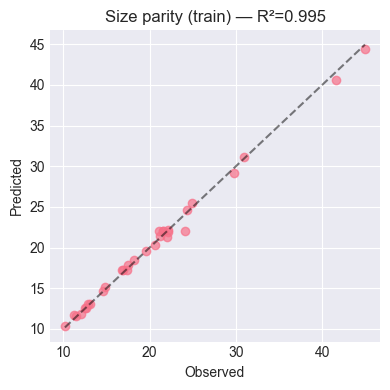

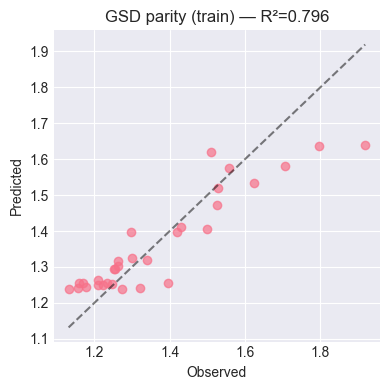

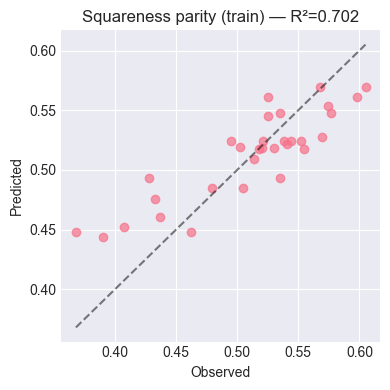


CROSS-VALIDATION PARITY (Generalization)


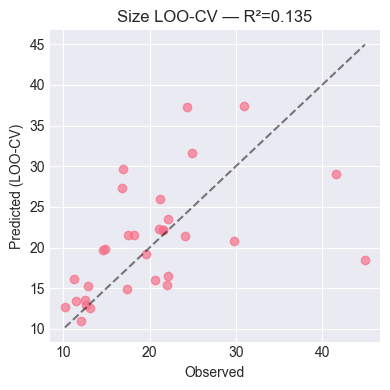

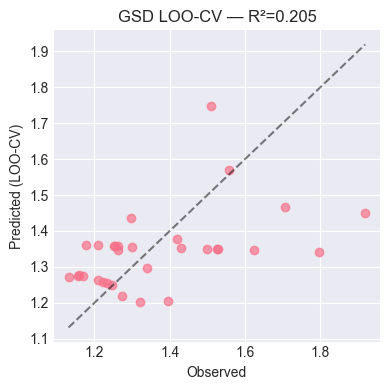

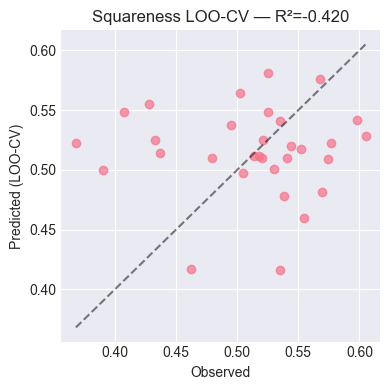


FEASIBILITY CLASSIFIER PERFORMANCE
HasProduct train AUC: 0.968
PhasePure train AUC: 0.956
IsCubic train AUC: 0.976

FACTOR IMPORTANCE (Inverse Lengthscales)


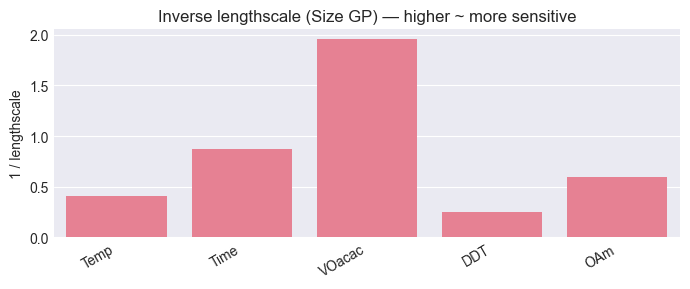


GSD MODEL SANITY CHECK
GSD coverage: within 1σ = 0.935, within 2σ = 1.000 (ideal ~0.68 / ~0.95)


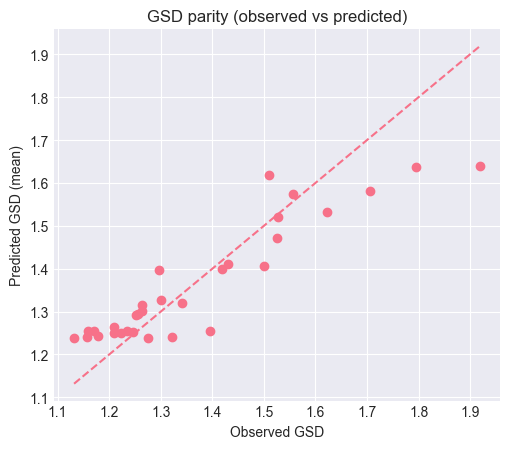

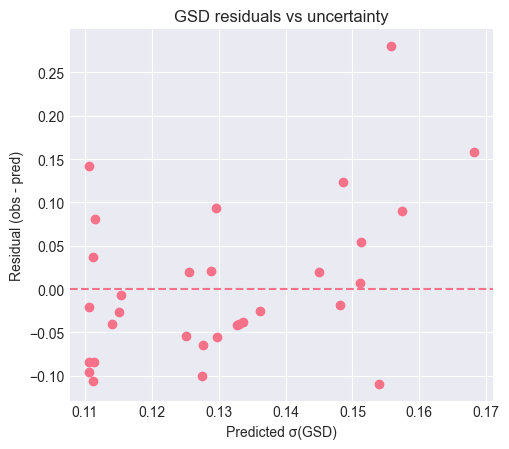

In [12]:
# =========================
# Run diagnostics
# =========================

# 1. Parity plots (training fit)
print("="*80)
print("PARITY PLOTS (Training Fit)")
print("="*80)
viz.plot_parity()

# 2. Cross-validation parity (generalization)
print("\n" + "="*80)
print("CROSS-VALIDATION PARITY (Generalization)")
print("="*80)
viz.plot_parity_cv()

# 3. Feasibility classifier performance
print("\n" + "="*80)
print("FEASIBILITY CLASSIFIER PERFORMANCE")
print("="*80)
viz.plot_feasibility_auc()

# 4. Factor importance (lengthscales)
print("\n" + "="*80)
print("FACTOR IMPORTANCE (Inverse Lengthscales)")
print("="*80)
viz.plot_lengthscales()

# 5. GSD sanity check
print("\n" + "="*80)
print("GSD MODEL SANITY CHECK")
print("="*80)
viz.plot_gsd_sanity()


## 10. Pareto Front Analysis

Analyze observed and predicted Pareto fronts.

**Observed**: Shows trade-offs in your actual experiments  
**Predicted**: Shows trade-offs in feasible candidate space


OBSERVED PARETO FRONT


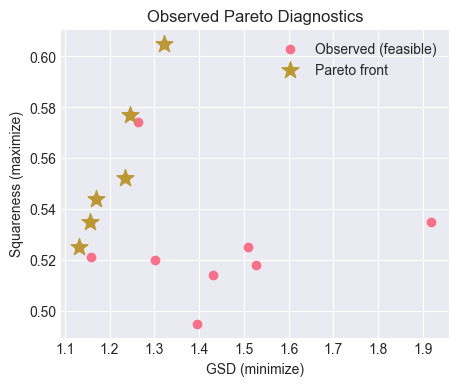

,Temp,Time,VOacac,DDT,OAm,Run_ID,GSD,Squareness,Size,PhasePure,HasProduct,Polymorph,IsCubic,ParetoObs
10,310,8,0.660,1.0,7.0,11,1.1319,0.525,14.865,1,1,cubic,1,True
11,310,8,0.660,5.0,1.0,12,1.1563,0.535,22.118,1,1,cubic,1,True
17,285,49,0.370,3.0,4.0,19,1.1709,0.544,21.524,1,1,cubic,1,True
16,285,49,0.370,3.0,4.0,18,1.2347,0.552,21.570,1,1,cubic,1,True
12,310,90,0.080,1.0,7.0,13,1.2458,0.577,14.544,1,1,cubic,1,True
26,310,8,0.660,1.0,1.0,28,1.3225,0.605,19.535,1,1,cubic,1,True
15,285,49,0.370,3.0,4.0,17,1.1591,0.521,21.038,1,1,cubic,1,False
39,309,9,0.146,2.1,4.8,33,1.2641,0.574,12.904,1,1,cubic,1,False
38,284,80,0.416,2.6,1.2,36,1.3011,0.520,16.920,1,1,cubic,1,False
18,285,49,0.370,3.0,4.0,20,1.3963,0.495,24.127,1,1,cubic,1,False



PREDICTED PARETO FRONT


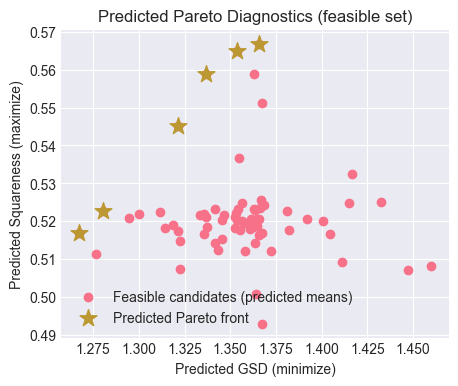

,Temp,Time,VOacac,DDT,OAm,Pred_Size,Pred_GSD,Pred_Squareness,P_SizeBand,P_Feasible
0,285.033056,52.800194,0.290021,4.125890,4.584749,18.399650,1.267336,0.516924,0.523189,0.735403
1,285.057203,67.334699,0.364399,2.818064,5.386760,17.986988,1.280228,0.522771,0.534148,0.740338
2,309.873824,31.868970,0.554972,2.419186,5.289032,21.651601,1.321704,0.545263,0.527974,0.660890
3,309.702174,22.731330,0.543944,1.546350,5.210647,19.335737,1.336779,0.558773,0.506686,0.607778
4,309.209374,40.033974,0.315412,2.193698,2.421633,21.724253,1.353488,0.565004,0.515003,0.624569
5,309.115182,17.366076,0.648994,1.303805,3.657974,19.832798,1.365881,0.566937,0.588348,0.604402



Found 6 Pareto optimal candidates

Top 5 Pareto candidates:
   Pred_Size  Pred_GSD  Pred_Squareness  P_SizeBand  P_Feasible
0  18.399650  1.267336         0.516924    0.523189    0.735403
1  17.986988  1.280228         0.522771    0.534148    0.740338
2  21.651601  1.321704         0.545263    0.527974    0.660890
3  19.335737  1.336779         0.558773    0.506686    0.607778
4  21.724253  1.353488         0.565004    0.515003    0.624569


In [13]:
# =========================
# Pareto Front Analysis
# =========================

# Observed Pareto front from experiments
print("="*80)
print("OBSERVED PARETO FRONT")
print("="*80)
df_obs_pareto = viz.plot_pareto_observed(require_feasible=True)

# Predicted Pareto front for target size
print("\n" + "="*80)
print("PREDICTED PARETO FRONT")
print("="*80)

target_size_nm = 20.0    # ← Change this to your target size
size_tol = 2.5
p_size_min = 0.5
p_feas_min = 0.6

df_pred_pareto = viz.plot_pareto_predicted(
    target_size=target_size_nm,
    size_tol=size_tol,
    p_size_min=p_size_min,
    p_feas_min=p_feas_min,
    candidate_pool=12000,
    seed=42
)

if df_pred_pareto is not None:
    print(f"\nFound {len(df_pred_pareto)} Pareto optimal candidates")
    print("\nTop 5 Pareto candidates:")
    print(df_pred_pareto[['Pred_Size', 'Pred_GSD', 'Pred_Squareness', 
                          'P_SizeBand', 'P_Feasible']].head())


## 11. Generate Recommendations

Get experimental recommendations for your target size.

**Parameters**:
- `target_size`: Desired particle size (nm)
- `size_tol`: Tolerance for size targeting (nm)
- `p_size_min`: Minimum probability of hitting size target (0-1)
- `p_feas_min`: Minimum feasibility probability (0-1)
- `n_return`: Number of diverse recommendations to return


In [14]:
# =========================
# Generate Recommendations
# =========================

target_size_nm = 20.0    # ← Your target size
size_tol = 2.5           # ± tolerance
p_size_min = 0.60        # Probability threshold
p_feas_min = 0.70

recommendations = bo.recommend_for_size(
    target_size=target_size_nm,
    size_tol=size_tol,
    p_size_min=p_size_min,
    p_feas_min=p_feas_min,
    candidate_pool=12000,
    min_distance=0.40,    # Ensure diversity
    n_return=5,           # Top 5 recommendations
    include_exploration_alt=True  # Include high-uncertainty option
)

print(f"\nTop {len(recommendations)} recommendations for {target_size_nm}nm:")
print("="*80)
display(recommendations)

# Save recommendations
recommendations.to_csv(f"recommendations_size_{target_size_nm}nm.csv", index=False)
print(f"\n✓ Saved to recommendations_size_{target_size_nm}nm.csv")



Top 5 recommendations for 20.0nm:


,Temp,Time,VOacac,DDT,OAm,target_size,size_tol,Pred_Size,Pred_Size_Std,Pred_GSD,Pred_GSD_Std,Pred_Squareness,Pred_Squareness_Std,P_SizeInBand,P_Feasible,AcqScore,ParetoPred,ParetoRankPred
0,285.214200,46.310887,0.324780,2.801643,4.909801,20.0,2.5,20.670897,2.451699,1.302857,0.159210,0.524961,0.044061,0.674237,0.746344,0.012642,True,0
1,284.553235,49.813007,0.342786,3.251564,3.637997,20.0,2.5,21.114980,1.772353,1.354935,0.183901,0.524128,0.043413,0.762041,0.751031,0.012160,False,1
2,284.807840,57.899020,0.354319,2.733003,1.862693,20.0,2.5,19.403181,2.584213,1.297494,0.155314,0.522707,0.044946,0.653888,0.720534,0.011504,True,0
3,284.725259,63.889218,0.390728,3.961605,3.741232,20.0,2.5,19.943675,2.633698,1.326033,0.173204,0.518387,0.046714,0.657389,0.747030,0.011286,False,1
4,284.268489,61.683137,0.344214,3.650231,4.681168,20.0,2.5,18.707897,2.201192,1.354479,0.180029,0.521650,0.044835,0.665944,0.726119,0.009429,False,1



✓ Saved to recommendations_size_20.0nm.csv


## 12. Multi-Size Sweep (Optional)

Generate recommendations across multiple target sizes.


In [15]:
# =========================
# Multi-Size Sweep (Optional)
# =========================

target_sizes = [10, 15, 20, 25, 30]  # nm

all_recommendations = []

for size in target_sizes:
    print(f"\n{'='*80}")
    print(f"TARGET SIZE: {size}nm")
    print('='*80)
    
    try:
        recs = bo.recommend_for_size(
            target_size=size,
            size_tol=2.5,
            p_size_min=0.55,
            p_feas_min=0.65,
            candidate_pool=10000,
            n_return=3
        )
        
        recs['TargetSize'] = size
        all_recommendations.append(recs)
        
        print(f"\nTop recommendation for {size}nm:")
        print(recs[FACTOR_ORDER + ['Pred_Size', 'Pred_GSD', 'Pred_Squareness']].iloc[0])
        
    except Exception as e:
        print(f"Could not generate recommendations for {size}nm: {e}")

if all_recommendations:
    df_all_recs = pd.concat(all_recommendations, ignore_index=True)
    print(f"\n✓ Generated {len(df_all_recs)} total recommendations across {len(target_sizes)} sizes")
    
    # Save
    df_all_recs.to_csv("recommendations_all_sizes.csv", index=False)
    print("✓ Saved to recommendations_all_sizes.csv")



TARGET SIZE: 10nm
Could not generate recommendations for 10nm: No candidates satisfied constraints. Try increasing size_tol or lowering p_size_min / p_feas_min, or expand bounds.

TARGET SIZE: 15nm

Top recommendation for 15nm:
Temp               284.893987
Time                80.695510
VOacac               0.275148
DDT                  2.299517
OAm                  3.419229
Pred_Size           14.387729
Pred_GSD             1.321822
Pred_Squareness      0.520153
Name: 0, dtype: float64

TARGET SIZE: 20nm

Top recommendation for 20nm:
Temp               309.826176
Time                10.424483
VOacac               0.657972
DDT                  3.524681
OAm                  1.596815
Pred_Size           21.686520
Pred_GSD             1.277232
Pred_Squareness      0.525784
Name: 0, dtype: float64

TARGET SIZE: 25nm

Top recommendation for 25nm:
Temp               285.125584
Time                39.697371
VOacac               0.405590
DDT                  3.238063
OAm                  3.83

## 13. Adaptive Surrogate Workflow (Optional)

Use the adaptive surrogate to propose experiments, register results, and update the model iteratively.

**Workflow**:
1. Propose next experiment
2. Run in lab
3. Register observed result
4. Model refits automatically
5. Repeat


In [16]:
# =========================
# Adaptive Surrogate Example
# =========================

# 1. Propose next experiment
proposal = bo.propose_next_experiment(
    target_size=20.0,
    size_tol=2.5,
    p_size_min=0.60,
    p_feas_min=0.70,
    candidate_pool=10000
)

print("PROPOSED EXPERIMENT:")
print("="*80)
print(f"Experiment ID: {proposal['exp_id']}")
print(f"\nConditions:")
for factor in FACTOR_ORDER:
    print(f"  {factor}: {proposal[factor]:.3f}")

print(f"\nPredicted outcomes:")
print(f"  Size: {proposal['Pred_Size']:.2f} ± {proposal['Pred_Size_Std']:.2f} nm")
print(f"  GSD: {proposal['Pred_GSD']:.3f} ± {proposal['Pred_GSD_Std']:.3f}")
print(f"  Squareness: {proposal['Pred_Squareness']:.3f} ± {proposal['Pred_Squareness_Std']:.3f}")
print(f"\nProbabilities:")
print(f"  P(size in target band): {proposal['P_SizeInBand']:.3f}")
print(f"  P(feasible): {proposal['P_Feasible']:.3f}")

print("\n" + "="*80)
print("⚠️  Run this experiment in the lab, then register the result:")
print("="*80)
print(f'''
# After running the experiment, register the observed result:
observed = {{
    "HasProduct": 1,        # 0 or 1
    "PhasePure": 1,         # 0 or 1
    "Size": 19.8,           # measured size (nm)
    "GSD": 1.25,            # measured GSD
    "Squareness": 0.58,     # measured squareness
    "Polymorph": "cubic",   # observed polymorph
    # "IsCubic": 1,         # optional, will be derived from Polymorph
}}

bo.register_experiment_result("{proposal['exp_id']}", observed, refit=True)
print("✓ Experiment registered and model refitted")
''')

# 2. Save state
bo.save_surrogate("current_surrogate_state")
print("\n✓ Surrogate state saved to 'current_surrogate_state/'")
print("  You can resume later with: bo = TargetedConstrainedBO.load_surrogate('current_surrogate_state')")


PROPOSED EXPERIMENT:
Experiment ID: exp_20260107_223523_20e221f0

Conditions:
  Temp: 285.222
  Time: 51.583
  VOacac: 0.323
  DDT: 4.044
  OAm: 2.559

Predicted outcomes:
  Size: 20.45 ± 2.45 nm
  GSD: 1.306 ± 0.161
  Squareness: 0.517 ± 0.048

Probabilities:
  P(size in target band): 0.684
  P(feasible): 0.722

⚠️  Run this experiment in the lab, then register the result:

# After running the experiment, register the observed result:
observed = {
    "HasProduct": 1,        # 0 or 1
    "PhasePure": 1,         # 0 or 1
    "Size": 19.8,           # measured size (nm)
    "GSD": 1.25,            # measured GSD
    "Squareness": 0.58,     # measured squareness
    "Polymorph": "cubic",   # observed polymorph
    # "IsCubic": 1,         # optional, will be derived from Polymorph
}

bo.register_experiment_result("exp_20260107_223523_20e221f0", observed, refit=True)
print("✓ Experiment registered and model refitted")


✓ Surrogate state saved to 'current_surrogate_state/'
  You can resume

## 14. Helper Diagnostics

Additional diagnostic functions for troubleshooting.


In [17]:
# =========================
# Temperature Diversity Diagnostic
# =========================

def check_temperature_diversity(bo):
    """Quick check for temperature recommendation diversity issues."""
    temp_col = "Temp"
    
    if temp_col not in bo.factor_order:
        print(f"Warning: '{temp_col}' not in factor_order")
        return
    
    temps = bo.df_feas[temp_col].values
    
    print("TEMPERATURE DIVERSITY CHECK")
    print("="*80)
    print(f"Unique temperatures: {len(np.unique(temps))}")
    print(f"Temperature range: [{temps.min():.1f}, {temps.max():.1f}]°C")
    print(f"\nDistribution:")
    print(bo.df_feas[temp_col].value_counts().sort_index())
    
    # Check lengthscale
    try:
        kernel = bo.gp_size.kernel_
        if hasattr(kernel, 'k1'):
            rbf = kernel.k1.k2 if hasattr(kernel.k1, 'k2') else kernel.k1
        else:
            rbf = kernel
        
        if hasattr(rbf, 'length_scale'):
            temp_idx = bo.factor_order.index(temp_col)
            temp_ls = rbf.length_scale[temp_idx]
            print(f"\nTemperature lengthscale: {temp_ls:.4f}")
            if temp_ls < 0.5:
                print("  ⚠️  Short lengthscale - model may not interpolate well")
    except:
        pass
    
    print("="*80)

# Run it
check_temperature_diversity(bo)


# =========================
# GSD Prediction Sanity Check
# =========================

def quick_gsd_check(bo, n_test=1000):
    """Verify GSD predictions are in the correct range."""
    X_test = bo.sample_candidates(n_test, seed=42)
    X_scaled = bo.scaler.transform(X_test)
    mu_g, sd_g = bo.predict_reg("GSD", X_scaled)
    
    print("\nGSD PREDICTION SANITY CHECK")
    print("="*80)
    print(f"Transform mode: {bo.gsd_transform}")
    print(f"\nPredictions (n={n_test}):")
    print(f"  Mean: {mu_g.mean():.4f}")
    print(f"  Std:  {mu_g.std():.4f}")
    print(f"  Range: [{mu_g.min():.4f}, {mu_g.max():.4f}]")
    
    print(f"\nTraining data:")
    gsd_train = bo.df_props["GSD"].values
    print(f"  Range: [{gsd_train.min():.4f}, {gsd_train.max():.4f}]")
    
    if mu_g.min() < 1.0 and gsd_train.min() > 1.0:
        print("\n  ✗ WARNING: Predictions in log space, training in raw space!")
        print("    Back-transformation may not be working correctly")
    elif mu_g.mean() > 0.1 and mu_g.mean() < 2.5:
        print("\n  ✓ Predictions in reasonable range")
    
    print("="*80)

# Run it
quick_gsd_check(bo)


# =========================
# Progress Tracking
# =========================

def track_optimization_progress(bo, target_sizes=[10, 15, 20, 25, 30]):
    """Track optimization progress across multiple target sizes."""
    progress = []
    
    for target in target_sizes:
        df_near = bo.df_feas[
            (bo.df_feas["Size"] >= target - 3) & 
            (bo.df_feas["Size"] <= target + 3)
        ]
        
        df_success = df_near[df_near["HasProduct"] == 1]
        
        if len(df_success) > 0:
            best_gsd = df_success["GSD"].min()
            best_sq = df_success["Squareness"].max()
            feas_rate = len(df_success) / len(df_near) if len(df_near) > 0 else 0
        else:
            best_gsd = np.nan
            best_sq = np.nan
            feas_rate = 0.0
        
        progress.append({
            "Target_Size": target,
            "N_Experiments": len(df_near),
            "N_Successful": len(df_success),
            "Feasibility_Rate": f"{feas_rate:.1%}",
            "Best_GSD": f"{best_gsd:.3f}" if not np.isnan(best_gsd) else "N/A",
            "Best_Squareness": f"{best_sq:.3f}" if not np.isnan(best_sq) else "N/A"
        })
    
    df_progress = pd.DataFrame(progress)
    
    print("\nOPTIMIZATION PROGRESS ACROSS SIZES")
    print("="*80)
    print(df_progress.to_string(index=False))
    print("="*80)
    
    return df_progress

# Run it
df_progress = track_optimization_progress(bo)


TEMPERATURE DIVERSITY CHECK
Unique temperatures: 14
Temperature range: [260.0, 310.0]°C

Distribution:
Temp
260    13
265     1
271     1
273     1
280     1
284     1
285     4
286     1
293     1
294     1
299     1
305     1
309     1
310    13
Name: count, dtype: int64

Temperature lengthscale: 2.4566

GSD PREDICTION SANITY CHECK
Transform mode: log

Predictions (n=1000):
  Mean: 1.3669
  Std:  0.0181
  Range: [1.2619, 1.6128]

Training data:
  Range: [1.1319, 1.9185]

  ✓ Predictions in reasonable range

OPTIMIZATION PROGRESS ACROSS SIZES
 Target_Size  N_Experiments  N_Successful Feasibility_Rate Best_GSD Best_Squareness
          10              7             7           100.0%    1.264           0.574
          15             11            11           100.0%    1.132           0.577
          20             12            12           100.0%    1.156           0.605
          25              6             6           100.0%    1.156           0.598
          30              2   

## 15. Save and Load State

Save your optimizer state to resume later.


In [18]:
# =========================
# Save Current State
# =========================

# Save the full optimizer state
save_path = "bo_state_" + datetime.now().strftime("%Y%m%d_%H%M%S")
bo.save_surrogate(save_path)
print(f"✓ Saved surrogate state to '{save_path}/'")

# =========================
# Load Previously Saved State
# =========================

# To resume from a saved state:
# bo_loaded = TargetedConstrainedBO.load_surrogate(save_path)
# viz = BOVisualizer(bo_loaded)
# print(f"✓ Loaded surrogate with {len(bo_loaded.df_feas)} experiments")


✓ Saved surrogate state to 'bo_state_20260107_143523/'


## 16. Troubleshooting Guide

Common issues and how to fix them.

### Issue 1: Pareto front shows constant GSD
**Cause**: GSD GP not using log transform  
**Fix**: Call `bo.refit_models()` after initialization

### Issue 2: Parity plot R² is negative
**Cause**: `plot_parity()` calling `gp.predict()` directly (returns log values)  
**Fix**: Ensure `plot_parity()` uses `bo.predict_reg()` instead

### Issue 3: Temperature stuck at 2 values
**Cause**: Training data clustered at a few temperatures, GP won't interpolate  
**Fix**: 
- Add experiments at intermediate temperatures
- Use `force_temperature_diversity()` helper
- Check `check_temperature_diversity(bo)` output

### Issue 4: No feasible candidates
**Cause**: Constraints too tight  
**Fix**:
- Lower `p_size_min` and `p_feas_min`
- Increase `size_tol`
- Increase `candidate_pool` size

### Issue 5: Model predictions don't improve
**Cause**: Not refitting after adding data  
**Fix**: Always use `refit=True` in `register_experiment_result()`

### Issue 6: Recommendations not diverse
**Cause**: `min_distance` too small  
**Fix**: Increase `min_distance` parameter (try 0.5-0.8)


## Summary

**Workflow**:
1. Load data
2. Build optimizer: `bo = TargetedConstrainedBO(...)`
3. Refit with log(GSD): `bo.refit_models()`
4. Run diagnostics: `viz.plot_parity()`, `viz.plot_pareto_observed()`, etc.
5. Generate recommendations: `bo.recommend_for_size(...)`
6. Run experiments in lab
7. Register results: `bo.register_experiment_result(..., refit=True)`
8. Save state: `bo.save_surrogate(...)`
9. Repeat steps 5-8

**Key Parameters**:
- `target_size`: Desired particle size (nm)
- `size_tol`: Size tolerance (nm)
- `p_size_min`: Probability threshold for size (0.5-0.7)
- `p_feas_min`: Probability threshold for feasibility (0.6-0.8)
- `objective_weights`: Balance between GSD and Squareness

**Files Generated**:
- `recommendations_size_XXnm.csv`: Recommended conditions for size XX
- `recommendations_all_sizes.csv`: Recommendations across multiple sizes
- `surrogate_state_*/`: Saved optimizer state

**Next Steps**:
1. Run recommended experiments
2. Register results and refit
3. Check progress with `track_optimization_progress(bo)`
4. Iterate until targets are met

For multi-size optimization strategy, see the separate guide files.


In [19]:
# Run this in a notebook cell to check:
import pandas as pd
print(pd.__version__)

# Try to trigger parquet
try:
    import pyarrow
    print(f"✓ pyarrow installed: {pyarrow.__version__}")
except ImportError:
    print("✗ pyarrow not found")

try:
    import fastparquet
    print(f"✓ fastparquet installed: {fastparquet.__version__}")
except ImportError:
    print("✗ fastparquet not found")

2.3.3
✓ pyarrow installed: 22.0.0
✗ fastparquet not found
